# MusicX — music habits and self-reported mental health

**Question.** Do listening habits help explain self-reported anxiety, depression, insomnia, and OCD? And how often do people say that music itself helps?

**Answer in one paragraph.** In this survey of 736 listeners, **74.5%** say music improves their mental health. Genre frequencies only weakly track the 0–10 symptom scores (largest Pearson *r* ≈ 0.19). A random forest on genres + age + hours **does not beat** a mean baseline. A model that *looks* perfect is often predicting the *sum of its own features*.


## 0 · Setup


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import (
    MENTAL_HEALTH_COLS,
    clean_survey,
    encode_frequencies,
    frequency_columns,
    genre_label,
    load_raw,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 13


## 1 · Data and quality

Source: [MxMH survey on Kaggle](https://www.kaggle.com/datasets/catherinerasgaitis/mxmh-survey-results) (Catherine Rasgaitis, Aug–Nov 2022). 736 rows, 33 columns. Genre listening is ordinal text; symptoms are 0–10 self-ratings.

Filling every missing cell with `0` turns a missing age into a newborn and a missing “Music effects” answer into the number 0. This analysis keeps missing as missing.


In [2]:
raw = load_raw()
print(f"rows={raw.shape[0]}  cols={raw.shape[1]}")
missing = raw.isna().sum()
print(missing[missing > 0].to_string())
print()
print("BPM max in the raw file:", f"{raw['BPM'].max():,.0f}")
print("Age missing:", raw["Age"].isna().sum())
print("Music effects missing:", raw["Music effects"].isna().sum())


rows=736  cols=33
Age                            1
Primary streaming service      1
While working                  3
Instrumentalist                4
Composer                       1
Foreign languages              4
BPM                          107
Music effects                  8

BPM max in the raw file: 999,999,999
Age missing: 1
Music effects missing: 8


In [3]:
clean = clean_survey(raw)
print("After cleaning — BPM max:", clean["BPM"].max())
print("BPM values discarded as outliers:", int(clean["BPM_outlier"].sum()))
print("Age still missing (not filled with 0):", int(clean["Age"].isna().sum()))
assert clean["Age"].isna().sum() == raw["Age"].isna().sum()
assert clean["BPM"].max() <= 300


After cleaning — BPM max: 220.0
BPM values discarded as outliers: 7
Age still missing (not filled with 0): 1


Encode the 16 `Frequency [*]` columns as Never=0, Rarely=1, Sometimes=2, Very frequently=3. That is an ordinal assumption — equal steps — but it is the standard way to put this survey into a correlation matrix.


In [4]:
df = encode_frequencies(clean)
freq_cols = frequency_columns(df)
print(len(freq_cols), "genre columns")
print([genre_label(c) for c in freq_cols])
df.head(3)


16 genre columns
['Classical', 'Country', 'EDM', 'Folk', 'Gospel', 'Hip hop', 'Jazz', 'K pop', 'Latin', 'Lofi', 'Metal', 'Pop', 'R&B', 'Rap', 'Rock', 'Video game music']


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,BPM_outlier
0,2022-08-27 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,2,3,0,2,3.0,0.0,1.0,0.0,NaN,False
1,2022-08-27 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,2,1,3,1,7.0,2.0,2.0,1.0,NaN,False
2,2022-08-27 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,0,1,1,3,7.0,7.0,10.0,2.0,No effect,False


## 2 · Who is in the sample

Median age 21, median 3 hours of music a day, 62% Spotify. This is a young, streaming-native convenience sample — not a population study.


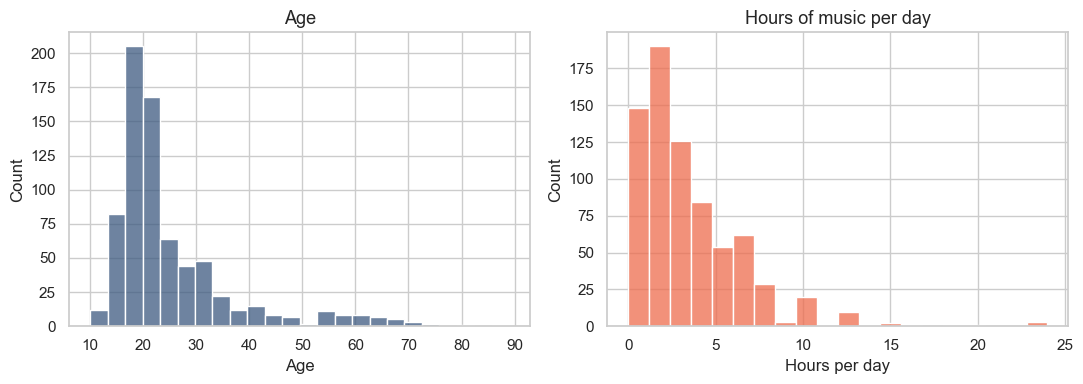

          Age  Hours per day
count  735.00         736.00
mean    25.21           3.57
std     12.05           3.03
min     10.00           0.00
25%     18.00           2.00
50%     21.00           3.00
75%     28.00           5.00
max     89.00          24.00

Primary streaming service
Spotify                              458
YouTube Music                         94
I do not use a streaming service.     71
Apple Music                           51
Other streaming service               50


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Age"].dropna(), bins=24, ax=axes[0], color="#3D5A80")
axes[0].set_title("Age")
sns.histplot(df["Hours per day"], bins=20, ax=axes[1], color="#EE6C4D")
axes[1].set_title("Hours of music per day")
fig.tight_layout()
plt.show()

print(df[["Age", "Hours per day"]].describe().round(2).to_string())
print()
print(df["Primary streaming service"].value_counts(dropna=False).head().to_string())


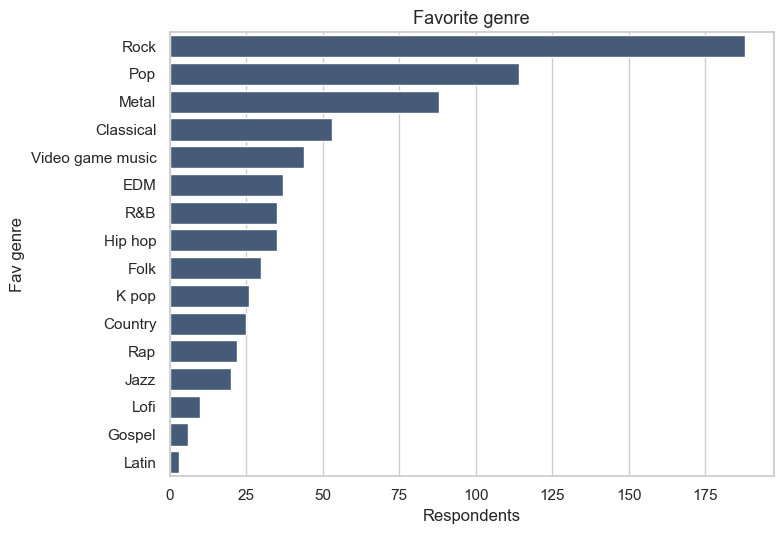

In [6]:
order = df["Fav genre"].value_counts().index
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.countplot(data=df, y="Fav genre", order=order, color="#3D5A80", ax=ax)
ax.set_title("Favorite genre")
ax.set_xlabel("Respondents")
fig.tight_layout()
plt.show()


## 3 · Symptom scores and the “music helps” question

Anxiety sits highest. OCD sits lowest. Anxiety and depression are the only pair with a moderate correlation (`r = 0.52`).


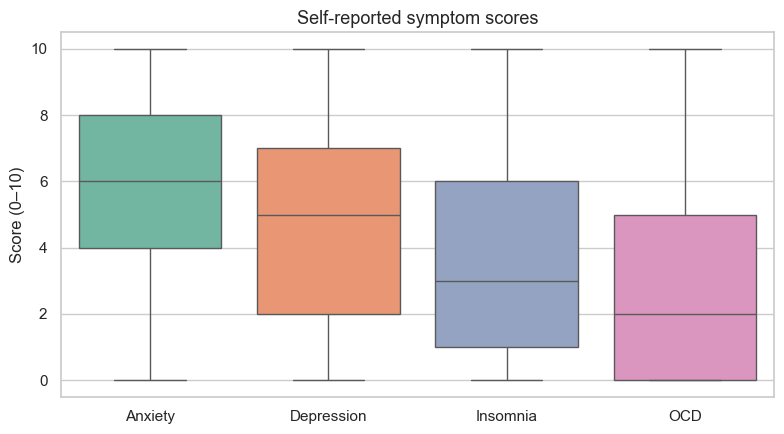

       Anxiety  Depression  Insomnia     OCD
count   736.00      736.00    736.00  736.00
mean      5.84        4.80      3.74    2.64
std       2.79        3.03      3.09    2.84
min       0.00        0.00      0.00    0.00
25%       4.00        2.00      1.00    0.00
50%       6.00        5.00      3.00    2.00
75%       8.00        7.00      6.00    5.00
max      10.00       10.00     10.00   10.00

Pearson among symptoms
            Anxiety  Depression  Insomnia    OCD
Anxiety       1.000       0.520     0.293  0.348
Depression    0.520       1.000     0.379  0.197
Insomnia      0.293       0.379     1.000  0.226
OCD           0.348       0.197     0.226  1.000


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df[MENTAL_HEALTH_COLS], ax=ax, palette="Set2")
ax.set_ylabel("Score (0–10)")
ax.set_title("Self-reported symptom scores")
fig.tight_layout()
plt.show()

print(df[MENTAL_HEALTH_COLS].describe().round(2).to_string())
print()
print("Pearson among symptoms")
print(df[MENTAL_HEALTH_COLS].corr().round(3).to_string())


Music effects
Improve      542
No effect    169
Worsen        17
Improve rate among non-missing: 74.5%


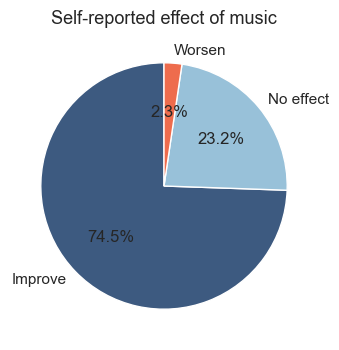

In [8]:
effects = df["Music effects"].dropna()
print(effects.value_counts().to_string())
print(f"Improve rate among non-missing: {(effects == 'Improve').mean():.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
counts = effects.value_counts().reindex(["Improve", "No effect", "Worsen"])
colors = ["#3D5A80", "#98C1D9", "#EE6C4D"]
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=colors, startangle=90)
ax.set_title("Self-reported effect of music")
plt.show()


In [9]:
print("Mean symptom score by reported music effect")
print(
    df.dropna(subset=["Music effects"])
    .groupby("Music effects")[MENTAL_HEALTH_COLS]
    .mean()
    .reindex(["Improve", "No effect", "Worsen"])
    .round(2)
    .to_string()
)


Mean symptom score by reported music effect
               Anxiety  Depression  Insomnia   OCD
Music effects                                     
Improve           6.05        4.86      3.76  2.72
No effect         5.12        4.38      3.67  2.36
Worsen            6.76        7.18      4.53  3.12


The 17 people who say music *worsens* their mental health also report much higher depression (7.2 vs 4.9). That cell is too small to turn into a percentage headline. It is a red flag worth a follow-up survey, not a finding to put on a slide without the *n*.


## 4 · Genre frequency vs. symptom scores

If a genre “went with” a symptom, we would see a clear band in this heatmap. We do not. The strongest links are Rock and Metal with depression, still below 0.20.


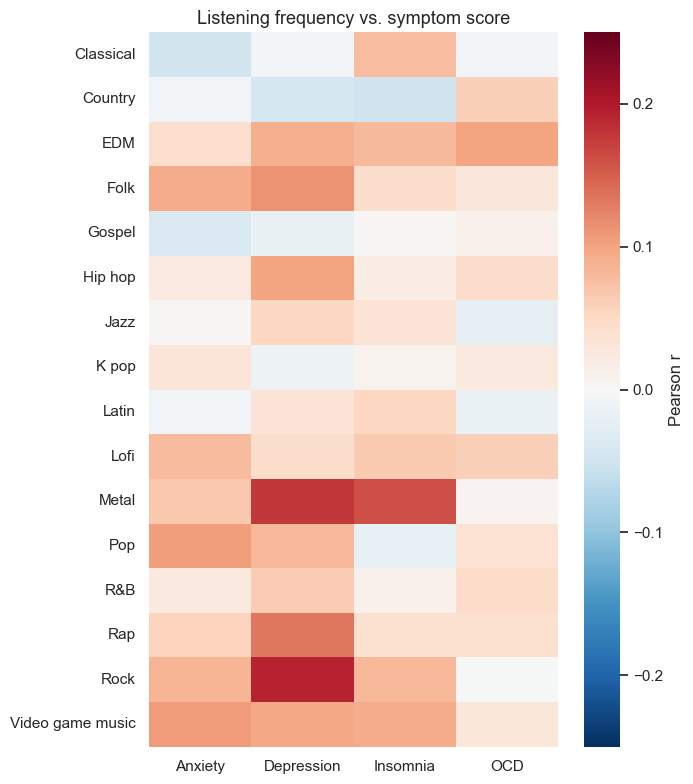

Largest |r| per symptom
  Anxiety: Video game music +0.107, Pop +0.104, Folk +0.092
  Depression: Rock +0.193, Metal +0.177, Rap +0.135
  Insomnia: Metal +0.161, Video game music +0.092, Rock +0.084
  OCD: EDM +0.099, Lofi +0.059, Country +0.059


In [10]:
corr = df[freq_cols + MENTAL_HEALTH_COLS].corr().loc[freq_cols, MENTAL_HEALTH_COLS]
corr.index = [genre_label(c) for c in corr.index]

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    vmin=-0.25,
    vmax=0.25,
    ax=ax,
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Listening frequency vs. symptom score")
fig.tight_layout()
plt.show()

print("Largest |r| per symptom")
for col in MENTAL_HEALTH_COLS:
    s = corr[col].abs().sort_values(ascending=False).head(3)
    signed = corr[col].reindex(s.index)
    print(f"  {col}: " + ", ".join(f"{i} {v:+.3f}" for i, v in signed.items()))


Favorite-genre “improve” rates look more exciting until you hide genres with *n* < 20. Lofi at 100% is ten people. Video game music (n = 44) is the large-enough genre with the lowest improve rate (~59%). Hip hop (n = 35) is among the highest (~89%). Still observational.


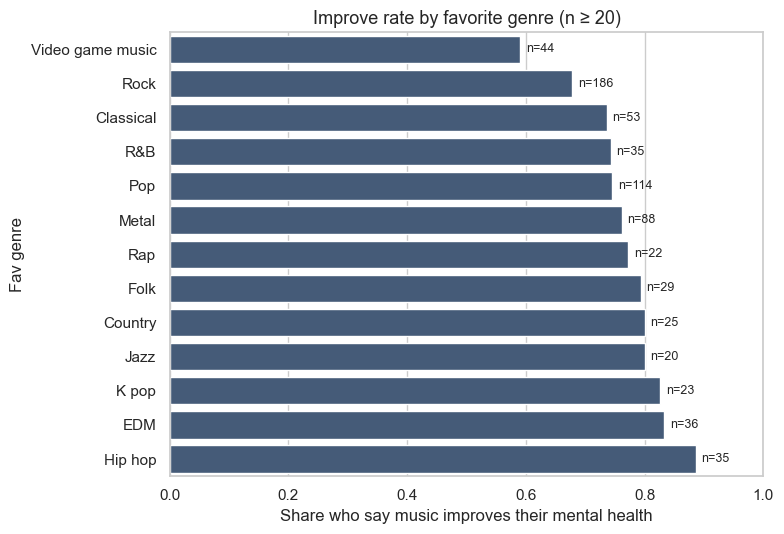

In [11]:
work = df.dropna(subset=["Music effects", "Fav genre"]).copy()
work["improves"] = work["Music effects"].eq("Improve")
summary = (
    work.groupby("Fav genre")
    .agg(n=("improves", "size"), improve_rate=("improves", "mean"))
    .query("n >= 20")
    .sort_values("improve_rate")
)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(
    data=summary.reset_index(),
    x="improve_rate",
    y="Fav genre",
    color="#3D5A80",
    ax=ax,
)
ax.set_xlabel("Share who say music improves their mental health")
ax.set_xlim(0, 1)
ax.set_title("Improve rate by favorite genre (n ≥ 20)")
for i, (_, row) in enumerate(summary.iterrows()):
    ax.text(row["improve_rate"] + 0.01, i, f"n={int(row['n'])}", va="center", fontsize=9)
fig.tight_layout()
plt.show()


## 5 · The leaked target

`TotalMusicFreq` was the sum of four encoded genre columns. Those four columns were then used to predict the sum. Linear regression should — and does — recover a coefficient of 1 for each of them.


In [12]:
four = [
    "Frequency [R&B]",
    "Frequency [Rap]",
    "Frequency [Rock]",
    "Frequency [Video game music]",
]
leaky = df.dropna(subset=four).copy()
leaky["TotalMusicFreq"] = leaky[four].sum(axis=1)

x = leaky[four]
y = leaky["TotalMusicFreq"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(x_train, y_train)
pred = lr.predict(x_test)
print("Linear regression on the leaked target")
print("  coefficients:", np.round(lr.coef_, 6))
print("  intercept   :", round(float(lr.intercept_), 12))
print("  test MSE    :", mean_squared_error(y_test, pred))
print("  test R²     :", r2_score(y_test, pred))


Linear regression on the leaked target
  coefficients: [1. 1. 1. 1.]
  intercept   : 0.0
  test MSE    : 2.358254369957577e-30
  test R²     : 1.0


That MSE is numerically zero. It is not a win. The model learned `y = x1 + x2 + x3 + x4` because that is how `y` was built.

Mental-health columns were also in the original feature list; they got coefficients of ~0 because they were irrelevant to a sum of frequencies. Feature importance in the random forest then “proved” that the genre columns mattered — of course they did: they *were* the target.


## 6 · Honest model: predict a symptom score

Features: 16 encoded genres + hours per day + age. Target: one of the 0–10 scores. Baseline: always predict the training-set mean (`DummyRegressor`). If the forest cannot beat that, listening habits are not a useful predictor in this sample.


In [13]:
def evaluate_target(frame: pd.DataFrame, target: str) -> dict:
    work = frame.dropna(subset=["Age", target]).copy()
    feats = freq_cols + ["Hours per day", "Age"]
    x_train, x_test, y_train, y_test = train_test_split(
        work[feats], work[target], test_size=0.2, random_state=42
    )
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(x_train, y_train)
    pred = rf.predict(x_test)
    dummy = DummyRegressor(strategy="mean").fit(x_train, y_train)
    base = dummy.predict(x_test)
    return {
        "target": target,
        "n": len(work),
        "rf_r2": r2_score(y_test, pred),
        "rf_mse": mean_squared_error(y_test, pred),
        "base_r2": r2_score(y_test, base),
        "base_mse": mean_squared_error(y_test, base),
        "importance": pd.Series(rf.feature_importances_, index=feats),
    }


rows = [evaluate_target(df, t) for t in MENTAL_HEALTH_COLS]
results = pd.DataFrame(rows)[["target", "n", "rf_r2", "base_r2", "rf_mse", "base_mse"]]
print(results.round(3).to_string(index=False))


    target   n  rf_r2  base_r2  rf_mse  base_mse
   Anxiety 735 -0.094   -0.035   8.152     7.714
Depression 735 -0.013   -0.005   8.467     8.399
  Insomnia 735 -0.090   -0.002   8.974     8.251
       OCD 735 -0.003   -0.017   9.786     9.925


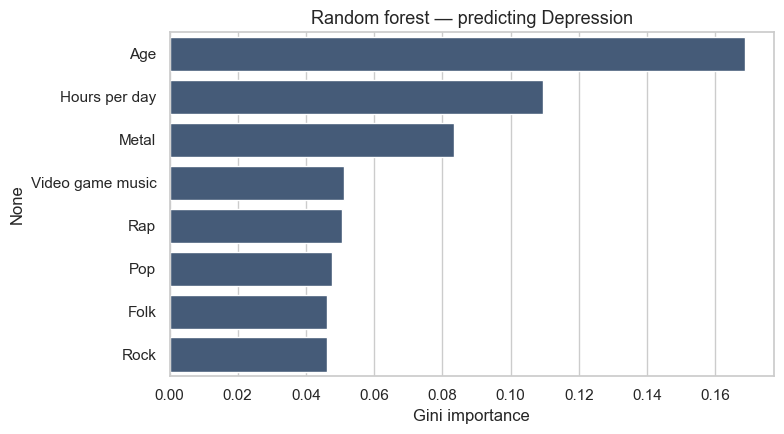

In [14]:
dep = next(r for r in rows if r["target"] == "Depression")
imp = (
    dep["importance"]
    .rename(index=lambda c: genre_label(c) if c.startswith("Frequency") else c)
    .sort_values(ascending=False)
    .head(8)
)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, color="#3D5A80", ax=ax)
ax.set_xlabel("Gini importance")
ax.set_title("Random forest — predicting Depression")
fig.tight_layout()
plt.show()


Age and hours dominate importance because they are the only continuous demographics in the feature set — not because they explain depression well. Test R² stays at or below the dummy baseline. **Do not ship this as a predictor.**

A classifier for “Improve vs not” has the same problem from the other side: the majority class is already 74.5%. Accuracy near that number is the base rate, not skill.


## 7 · What this is allowed to claim

**Can claim**

- Most respondents in this survey *say* music helps.
- Symptom scores are internally coherent (anxiety–depression *r* = 0.52).
- Genre–symptom correlations exist and are small.
- The leaked target (`TotalMusicFreq` as a sum of its own features) was not a mental-health model.

**Cannot claim**

- That a genre causes (or treats) a diagnosis.
- That the 17-person “Worsen” group represents a population rate.
- That a recommender or clinical tool should be built from these 736 rows.

The dashboard in `app.py` is an explorer for these tables, not a diagnostic product.
